In [120]:
import torch
import torchvision
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.io import read_image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import os
from datetime import datetime
from generative.inferers import DiffusionInferer
from monai.networks.schedulers import DDIMScheduler
from tqdm import tqdm
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.autograd.set_detect_anomaly(True)


Using device: cpu


In [121]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = [item for item in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir,item))]
        self.image_paths = []
        self.labels = []
        
        # Collect image file paths and corresponding labels
        for label in self.classes:
            class_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_name))
                self.labels.append(self.classes.index(label))  # Assign numeric labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = read_image(img_path)  # Load the image
        image = image.float() / 255.0
        label = self.labels[idx]       # Get the label
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    # transforms.ToTensor(),           # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize
])

Input shape: torch.Size([8, 3, 128, 128])
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0])


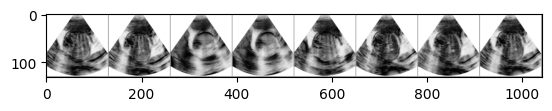

In [122]:
# Specify the path to your dataset
root_dir = '/mnt/raid/home/ajarry/data/trainer'
train_dir = os.path.join(root_dir,"train")
val_dir = os.path.join(root_dir,"labels")

# Create dataset instance
# custom_dataset = CustomImageDataset(root_dir=root_dir, transform=transform)
train_dataset = CustomImageDataset(root_dir=train_dir,transform=transform)
val_dataset = CustomImageDataset(root_dir=val_dir,transform=transform)

# View some examples
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

x, y = next(iter(train_dataloader))
print("Input shape:", x.shape)
print("Labels:", y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")


In [123]:
def linear_beta_schedule(timesteps, start=1e-4, end=2e-2):
    return torch.linspace(start, end, timesteps)

# Set hyperparameters for the scheduler
T = 1000  # Number of timesteps
betas = linear_beta_schedule(T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]], dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)


In [124]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation with time embedding."""

    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 128, kernel_size=5, padding=2),
                nn.Conv2d(128, 128, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(128, 128, kernel_size=5, padding=2),
                nn.Conv2d(128, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.ReLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

        # Optional: add a linear layer to process t_emb and match it to channel dimensions
        self.time_embed = nn.Linear(1, 128)

    def forward(self, x, t_emb):
        # Expand t_emb to have the correct shape and process it with the linear layer
        t_emb = self.time_embed(t_emb).view(-1, 128, 1, 1)

        h = []
        # Down-sampling layers
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))
            
            # Add time embedding to feature maps
            if x.shape[1] == t_emb.shape[1]:  # Check if channels match for addition
                x = x + t_emb

            if i < len(self.down_layers) - 1:
                h.append(x)  # Store output for skip connections
                x = self.downscale(x)

        # Up-sampling layers
        for i, l in enumerate(self.up_layers):
            if i > 0:
                x = self.upscale(x)
                x = x + h.pop()  # Add skip connection

            x = self.act(l(x))

            # Add time embedding to feature maps
            if x.shape[1] == t_emb.shape[1]:  # Ensure channels match for addition
                x = x + t_emb

        return x


In [125]:
def forward_diffusion(x_0, t):
    noise = torch.randn_like(x_0)
    
    # Get the noise scaling factors for each item in the batch
    sqrt_alpha_t = sqrt_alphas_cumprod.gather(0, t).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod.gather(0, t).view(-1, 1, 1, 1)
    
    # Apply the diffusion process
    x_t = sqrt_alpha_t * x_0 + sqrt_one_minus_alpha_t * noise
    return x_t, noise


In [126]:
# Hyperparameters
batch_size = 32
lr = 1e-5
epochs = 5000
num_workers = 4


# Dataset and DataLoader
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure one-channel grayscale
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


train_dataloader = DataLoader(train_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)


# Initialize model, optimizer, and loss function
model = BasicUNet()
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# Function to evaluate the model on the validation set
def validate(model, val_dataloader):
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    with torch.no_grad():  # Disable gradient computation
        for x_0, _ in val_dataloader:
            x_0 = x_0.to(device)

             # Use the batch size of x_0 for t in case it's a partial batch
            current_batch_size = x_0.size(0)
            t = torch.randint(0, T, (current_batch_size,)).to(device)

            # Forward diffusion process
            x_t, noise = forward_diffusion(x_0, t)

            # Predict the noise using the model
            t_emb = (t / T).float().unsqueeze(1)  # Time embedding
            noise_pred = model(x_t, t_emb)

            # Compute the loss
            loss = criterion(noise_pred, noise)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)  # Calculate average validation loss
    return avg_val_loss

# Training loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    train_loss = 0.0
    for x_0, _ in tqdm(train_dataloader):
        x_0 = x_0.to(device)
        
        # Use the batch size of x_0 for t in case it's a partial batch
        current_batch_size = x_0.size(0)
        t = torch.randint(0, T, (current_batch_size,)).to(device)

        # Forward diffusion process
        x_t, noise = forward_diffusion(x_0, t)
        
        # Predict the noise using the model
        t_emb = (t / T).float().unsqueeze(1)  # Time embedding
        noise_pred = model(x_t, t_emb.to(device))

        # Compute the loss
        loss = criterion(noise_pred, noise)
        train_loss += loss.item()

        # Backpropagation and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = train_loss / len(train_dataloader)  # Calculate average training loss
    avg_val_loss = validate(model, val_dataloader)  # Validate the model

    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:10<00:00,  1.14s/it]


Epoch 1/5000, Training Loss: 1.0138, Validation Loss: 1.0093


100%|██████████| 9/9 [00:10<00:00,  1.17s/it]


Epoch 2/5000, Training Loss: 1.0047, Validation Loss: 1.0015


...

Epoch 4998/5000, Training Loss: 0.5369, Validation Loss: 0.5147


100%|██████████| 9/9 [00:08<00:00,  1.07it/s]


Epoch 4999/5000, Training Loss: 0.5300, Validation Loss: 0.5336


100%|██████████| 9/9 [00:07<00:00,  1.15it/s]


Epoch 5000/5000, Training Loss: 0.5355, Validation Loss: 0.5334


In [129]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"outputs_v2/output_{timestamp}/"
os.makedirs(output_dir, exist_ok=True)

final_model_path = os.path.join(output_dir, "model.pth")
torch.save(model.state_dict(), final_model_path)

torch.Size([1, 3, 128, 128])
torch.Size([1, 3, 128, 128])
torch.Size([1, 3, 128, 128])
torch.Size([1, 3, 128, 128])
torch.Size([3, 128, 128])
(128, 128, 3)


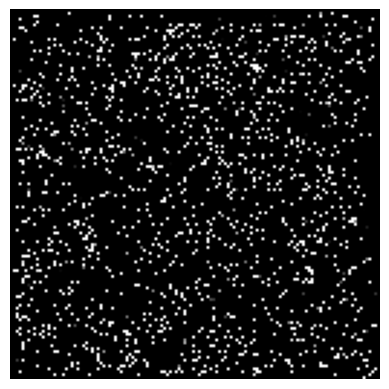

In [150]:
def sample(model, steps, shape=(1, 3, 128, 128)):
    x_t = torch.randn(shape)  # Start with random noise
    x_t = x_t.to(device)
    for t in reversed(range(steps)):
        t_tensor = torch.tensor([t / T]).float().unsqueeze(1)
        noise_pred = model(x_t, t_tensor)
        x_t = (1 / torch.sqrt(alphas[t])) * (x_t - betas[t] * noise_pred / torch.sqrt(1 - alphas[t]))
        if t > 0:
            noise = torch.randn_like(x_t)
            x_t += torch.sqrt(betas[t]) * noise
    return x_t

# Assuming `sample` is your function that generates the image tensor
# Example: generated_image = sample(model, steps=1000)  # Use the sample method to generate the image

# Generate an image with your model (modify shape and steps as needed)
generated_image = sample(model, steps=1000)  # Pass in the model and number of steps
print(generated_image.shape)

# Detach the image from the computation graph and move it to the CPU if necessary
generated_image = generated_image.detach().cpu()
print(generated_image.shape)

# Normalize to [0, 1] range if necessary (if image is in range [-1, 1] or any other range)
generated_image = (generated_image + 1) / 2  # Normalize to [0, 1]
print(generated_image.shape)

# Ensure values are within [0, 1] for display
generated_image = torch.clamp(generated_image, 0.0, 1.0)
print(generated_image.shape)

# If the image has shape (1, 1, H, W), squeeze dimensions for display
generated_image = generated_image.squeeze()  # Removes unnecessary dimensions
print(generated_image.shape)

generated_image = generated_image.cpu().numpy().transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)

# Display the image in grayscale
print(generated_image.shape)
plt.imshow(generated_image[:,:,0], cmap='gray')  # Specify the colormap to be gray
plt.axis("off")
plt.show()

(560, 672, 3)


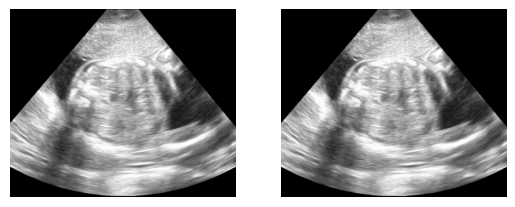

In [151]:
x = '/mnt/raid/home/ajarry/data/trainer/train/true_train/001fb195-949f-463e-83b0-ac3a092cb064_frame_0.png'
im = plt.imread(x)
print(im.shape)
plt.subplot(121)
plt.imshow(im)
plt.axis("off")

plt.subplot(122)
plt.imshow(im,cmap='gray')
plt.axis("off")

plt.show()